In [3]:
import plotly.express as px 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 

In [78]:
df = pd.read_csv('movies_updated.csv')
df.head(2)

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,"runtime,,"
0,The Shining,R,Drama,1980,"June 13, 1980 (United States)",8.4,927000,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,19000000,46998772.0,Warner Bros.,"146.0,"
1,The Blue Lagoon,R,Adventure,1980,"July 2, 1980 (United States)",5.8,65000,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000,58853106.0,Columbia Pictures,"104.0,"


#### Exercise 1 

In [23]:
df.head(5)
len(df), len(df.columns)
df.columns
df.dtypes
# we can sumarize it by just using df.info

name          object
rating        object
genre         object
year           int64
released      object
score        float64
votes          int64
director      object
writer        object
star          object
country       object
budget         int64
gross        float64
company       object
runtime,,     object
dtype: object

#### Exercise 2

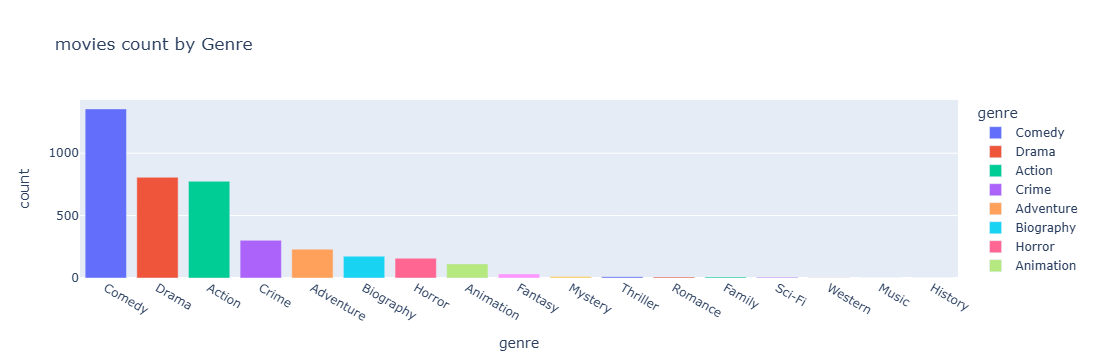

In [55]:
movie_count_by_genre = df['genre'].value_counts().reset_index()
movie_count_by_genre.columns = ['genre', 'count',]
px.bar(movie_count_by_genre, 'genre', 'count',title='movies count by Genre', color='genre')
#can simply use histogram since it automatically aggregates px.histogram(df,'genre')

#### Exercise 3

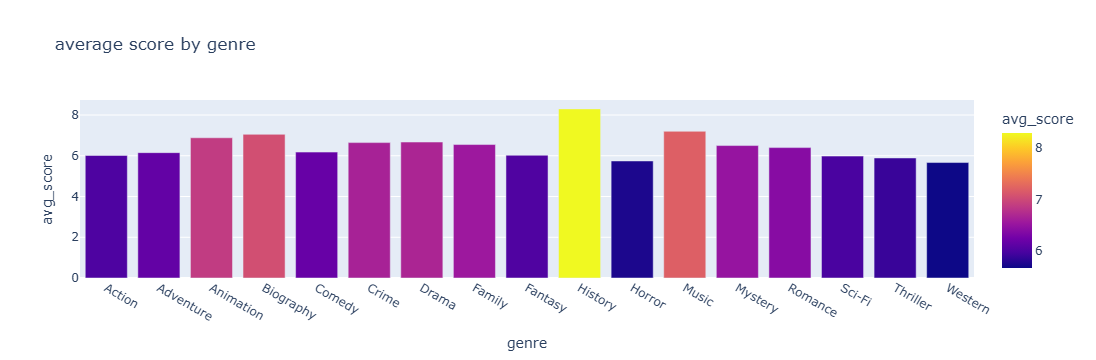

In [56]:
genre_scores = df.groupby('genre')['score'].mean().reset_index()
genre_scores.columns = ['genre', 'avg_score']
px.bar(genre_scores, 'genre', 'avg_score', title='average score by genre', color='avg_score')

#### Exercise 4

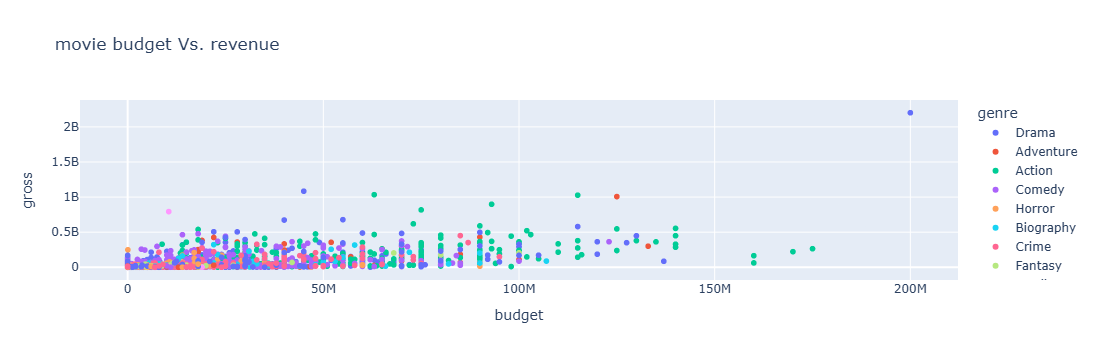

In [54]:
px.scatter(df, 'budget', 'gross', title='movie budget Vs. revenue', hover_name='name', color='genre')

#### Exercise 5 

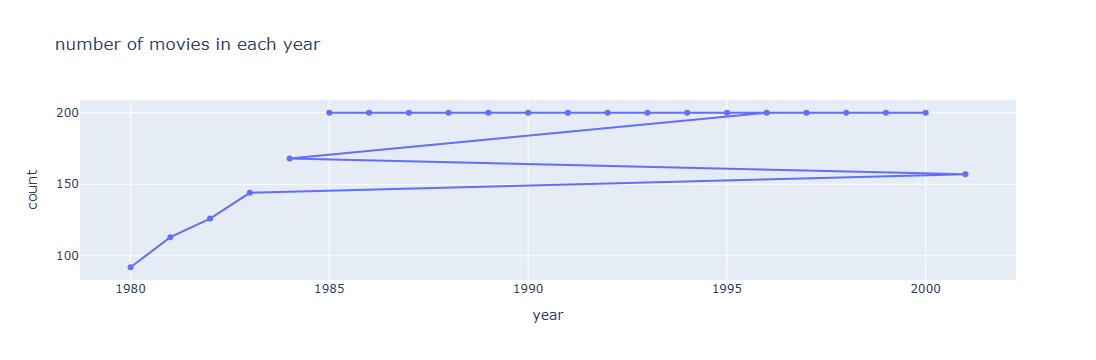

In [70]:
movie_count_by_year = df['year'].value_counts().reset_index()
movie_count_by_year.columns = ['year', 'count']
px.line(movie_count_by_year, 'year', 'count', markers='s', title='number of movies in each year')
# px.histogram(df, 'year')

#### Exercise 6 

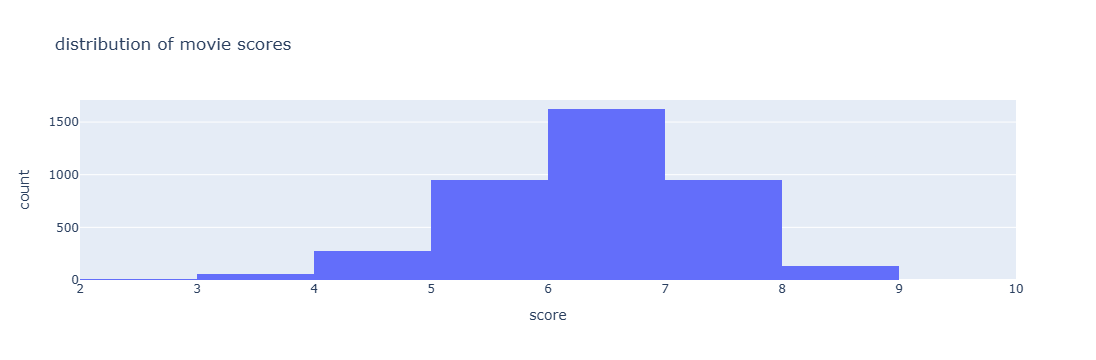

In [77]:
px.histogram(df, 'score', nbins=10, title='distribution of movie scores')

#### Exercise 7 

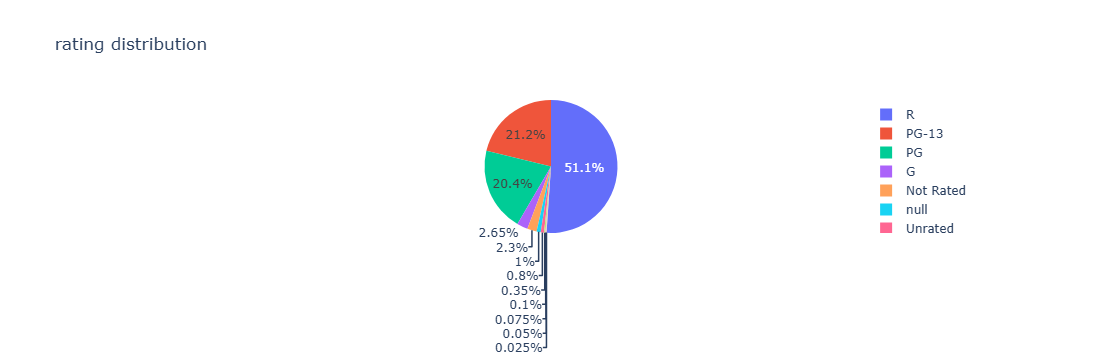

In [87]:
px.pie(df, 'rating', title='rating distribution')

#### Exercise 8

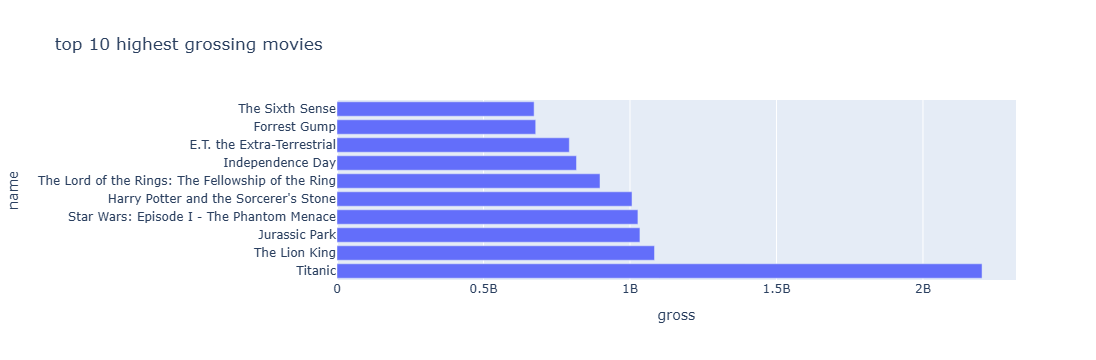

In [88]:
top_gross = df[['name', 'gross']].sort_values(by='gross', ascending=False).head(10)
px.bar(top_gross, 'gross', 'name' , orientation='h', title='top 10 highest grossing movies')

### DASH

In [89]:
pip install dash jupyter-dash   

Defaulting to user installation because normal site-packages is not writeable
  Using cached dash-4.3.0-py3-none-any.whl.metadata (11 kB)
  Using cached retrying-1.4.2-py3-none-any.whl.metadata (5.5 kB)
  Using cached janus-2.0.0-py3-none-any.whl.metadata (5.3 kB)
  Using cached mcp-1.28.0-py3-none-any.whl.metadata (9.4 kB)
  Using cached httpx_sse-0.4.3-py3-none-any.whl.metadata (9.7 kB)
  Using cached python_multipart-0.0.32-py3-none-any.whl.metadata (2.1 kB)
  Using cached sse_starlette-3.4.5-py3-none-any.whl.metadata (15 kB)
  Using cached starlette-1.3.1-py3-none-any.whl.metadata (6.4 kB)
  Using cached uvicorn-0.49.0-py3-none-any.whl.metadata (6.7 kB)
Using cached dash-4.3.0-py3-none-any.whl (8.4 MB)
Using cached janus-2.0.0-py3-none-any.whl (12 kB)
Using cached mcp-1.28.0-py3-none-any.whl (221 kB)
Using cached httpx_sse-0.4.3-py3-none-any.whl (9.0 kB)
Using cached python_multipart-0.0.32-py3-none-any.whl (30 kB)
Using cached sse_starlette-3.4.5-py3-none-any.whl (16 kB)
Using cac

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [90]:
from dash import Dash, dcc, html, Input, Output

In [111]:
options = [{'label': genre, 'value': genre} for genre in df['genre'].unique()]

app = Dash(__name__)
app.layout = html.Div([
 html.H1('Average movie score by rating'),
 dcc.Dropdown(
 id="dropdown",
 options=options,
 value="Animation",
 clearable=False,
 ),
 dcc.Graph(id="graph"),
])

@app.callback(
 Output("graph", "figure"),
 Input("dropdown", "value"))
def update_bar_chart(selected_genre):
    # Filter the DataFrame by the selected genre
    filtered_df = df[df['genre'] == selected_genre]
    
    # Group by 'rating' and calculate the mean of 'score'
    agg_df = filtered_df.groupby('rating', as_index=False)['score'].mean()
    
    fig = px.bar(
        agg_df, 
        x="rating", 
        y="score", 
        title=f"Average Score by Rating for {selected_genre}",
        labels={"score": "Average Score", "rating": "Rating"}
    )
    
    return fig
app.run(debug=True)
